DATA PROCESSING

In [49]:
# Import packages
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors
from rdkit.Chem import PandasTools

# Visualization and analysis libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style for better visualizations
plt.style.use("default")
sns.set_palette("husl")


In [37]:
#loading
df = pd.read_csv('train.csv')  

In [38]:
#Get dataset size
print(f'Shape of train.csv: {df.shape}')

Shape of train.csv: (7973, 7)


7 Feature columns, 7973 datapoints

In [39]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7973 entries, 0 to 7972
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       7973 non-null   int64  
 1   SMILES   7973 non-null   object 
 2   Tg       511 non-null    float64
 3   FFV      7030 non-null   float64
 4   Tc       737 non-null    float64
 5   Density  613 non-null    float64
 6   Rg       614 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 436.2+ KB


,id,Tg,FFV,Tc,Density,Rg
count,7.973000e+03,511.000000,7030.000000,737.000000,613.000000,614.000000
mean,1.080050e+09,96.452314,0.367212,0.256334,0.985484,16.419787
std,6.218241e+08,111.228279,0.029609,0.089538,0.146189,4.608640
min,8.781700e+04,-148.029738,0.226992,0.046500,0.748691,9.728355
25%,5.376641e+08,13.674509,0.349549,0.186000,0.890243,12.540328
50%,1.079079e+09,74.040183,0.364264,0.236000,0.948193,15.052194
75%,1.621708e+09,161.147595,0.380790,0.330500,1.062096,20.411067
max,2.147438e+09,472.250000,0.777097,0.524000,1.840999,34.672906


Canonicalizing SMILES

In [40]:
# A function to canonicalize isomeric SMILES
def canonicalize_smiles(smiles, isomeric:bool=True):
    """
    Convert any SMILES to its canonical form.

    Args:
        smiles (str): Input SMILES string

    Returns:
        str: Canonical SMILES
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None  # Invalid SMILES
    return Chem.MolToSmiles(mol, isomericSmiles=isomeric)


In [41]:
# Apply the 'canonicalize_smiles' function to the column ['smiles'] and store in new column ['canonical_smiles']
df['canonical_smiles'] = df['SMILES'].apply(canonicalize_smiles)

# create a DataFrame subset with the entries that are different canonicalized
changed = df[df['SMILES'] != df['canonical_smiles']]

print(f"Total changed: {len(changed)}")


Total changed: 17


Checking for Duplicates

In [42]:
# Count the unique values with .nunique()
unique_smiles = df['SMILES'].nunique()
unique_canonical = df['canonical_smiles'].nunique()

print(f'Unique SMILES: {unique_smiles}')
print(f'Unique canonical SMILES: {unique_canonical}')


Unique SMILES: 7973
Unique canonical SMILES: 7973


17 SMILES were canonicalized, but all SMILES (and polymers) are still unique.

In [ ]:
# Add a column called 'molecule' with mol objects
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='canonical_smiles', molCol='molecule')

In [50]:
def calculate_key_descriptors(mol):
    """Calculate RDKit molecular descriptors for a molecule."""
    if mol is None:
        return {
            'MW': None,
            'LogP': None,
            'TPSA': None,
            'HBD': None,
            'HBA': None,
            'RotBonds': None,
            'NumHeavyAtoms': None,
            'NumHeteroatoms': None,
            'RingCount': None,
            'NumAromaticRings': None,
            'FractionCSP3': None
        }

    descriptors = {
        'MW': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'HBD': Descriptors.NumHDonors(mol),
        'HBA': Descriptors.NumHAcceptors(mol),
        'RotBonds': Descriptors.NumRotatableBonds(mol),
        'NumHeavyAtoms': mol.GetNumHeavyAtoms(),
        'NumHeteroatoms': Descriptors.NumHeteroatoms(mol),
        'RingCount': Descriptors.RingCount(mol),
        'NumAromaticRings': Descriptors.NumAromaticRings(mol),
        'FractionCSP3': Descriptors.FractionCSP3(mol)
    }

    return descriptors


Apply calculate_key_descriptors to mol objects in the DataFrame

In [ ]:
descriptor_data = []
for idx, mol in df['molecule'].items():
    desc = calculate_key_descriptors(mol)
    descriptor_data.append(desc)

# Create descriptor DataFrame with pd.DataFrame()
# We use the same index as the original DataFrame to maintain row alignment
descriptor_df = pd.DataFrame(descriptor_data, index=df.index)

# Combine with the original molecules DataFrame
df_with_descriptors = pd.concat([df, descriptor_df], axis=1)

# Check the new dimensions - we should have the same number of rows but more columns
print(f"Dataset shape: {df_with_descriptors.shape}")
display(df_with_descriptors.head())

Dataset shape: (7973, 20)


,id,SMILES,Tg,FFV,Tc,Density,Rg,canonical_smiles,molecule,MW,LogP,TPSA,HBD,HBA,RotBonds,NumHeavyAtoms,NumHeteroatoms,RingCount,NumAromaticRings,FractionCSP3
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,NaN,0.374645,0.205667,NaN,NaN,*CC(*)c1ccccc1C(=O)OCCCCCC,<rdkit.Chem.rdchem.Mol object at 0x742cc5ed3680>,232.323,3.98170,26.30,0,2,8,17,4,1,1,0.533333
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,NaN,0.370410,NaN,NaN,NaN,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,<rdkit.Chem.rdchem.Mol object at 0x742cc5ed3530>,598.919,12.35960,24.06,2,2,16,45,4,5,4,0.441860
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,NaN,0.378860,NaN,NaN,NaN,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,<rdkit.Chem.rdchem.Mol object at 0x742cc5ed3610>,1003.207,14.21700,122.27,0,9,15,73,13,10,8,0.145161
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,NaN,0.387324,NaN,NaN,NaN,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,<rdkit.Chem.rdchem.Mol object at 0x742cc5ed3840>,542.726,11.00768,24.06,2,2,7,42,4,6,6,0.100000
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,NaN,0.355470,NaN,NaN,NaN,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,<rdkit.Chem.rdchem.Mol object at 0x742cc5ed36f0>,965.154,11.84500,182.28,0,14,34,70,18,6,4,0.518519


11 RDKit features added to the dataframe.

In [52]:
df_with_descriptors.info()
df_with_descriptors.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7973 entries, 0 to 7972
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                7973 non-null   int64  
 1   SMILES            7973 non-null   object 
 2   Tg                511 non-null    float64
 3   FFV               7030 non-null   float64
 4   Tc                737 non-null    float64
 5   Density           613 non-null    float64
 6   Rg                614 non-null    float64
 7   canonical_smiles  7973 non-null   object 
 8   molecule          7973 non-null   object 
 9   MW                7973 non-null   float64
 10  LogP              7973 non-null   float64
 11  TPSA              7973 non-null   float64
 12  HBD               7973 non-null   int64  
 13  HBA               7973 non-null   int64  
 14  RotBonds          7973 non-null   int64  
 15  NumHeavyAtoms     7973 non-null   int64  
 16  NumHeteroatoms    7973 non-null   int64  


,id,Tg,FFV,Tc,Density,Rg,MW,LogP,TPSA,HBD,HBA,RotBonds,NumHeavyAtoms,NumHeteroatoms,RingCount,NumAromaticRings,FractionCSP3
count,7.973000e+03,511.000000,7030.000000,737.000000,613.000000,614.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000
mean,1.080050e+09,96.452314,0.367212,0.256334,0.985484,16.419787,442.483920,5.572282,66.111084,0.872445,4.414649,9.006397,32.280070,8.234792,3.674652,3.038003,0.342673
std,6.218241e+08,111.228279,0.029609,0.089538,0.146189,4.608640,239.991773,3.702220,47.088447,1.245024,2.920745,6.465652,17.963829,4.602030,3.081068,2.625130,0.319564
min,8.781700e+04,-148.029738,0.226992,0.046500,0.748691,9.728355,14.027000,-4.822900,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000
25%,5.376641e+08,13.674509,0.349549,0.186000,0.890243,12.540328,258.409000,2.904340,26.300000,0.000000,2.000000,5.000000,18.000000,5.000000,1.000000,1.000000,0.060606
50%,1.079079e+09,74.040183,0.364264,0.236000,0.948193,15.052194,406.357000,5.048500,58.200000,0.000000,4.000000,7.000000,29.000000,7.000000,3.000000,3.000000,0.250000
75%,1.621708e+09,161.147595,0.380790,0.330500,1.062096,20.411067,580.643000,7.458800,95.120000,2.000000,6.000000,12.000000,43.000000,10.000000,6.000000,4.000000,0.533333
max,2.147438e+09,472.250000,0.777097,0.524000,1.840999,34.672906,2202.482000,31.011400,437.260000,9.000000,45.000000,92.000000,164.000000,54.000000,18.000000,16.000000,1.000000


Data Visualization

Distribution Plots for Each Descriptor:

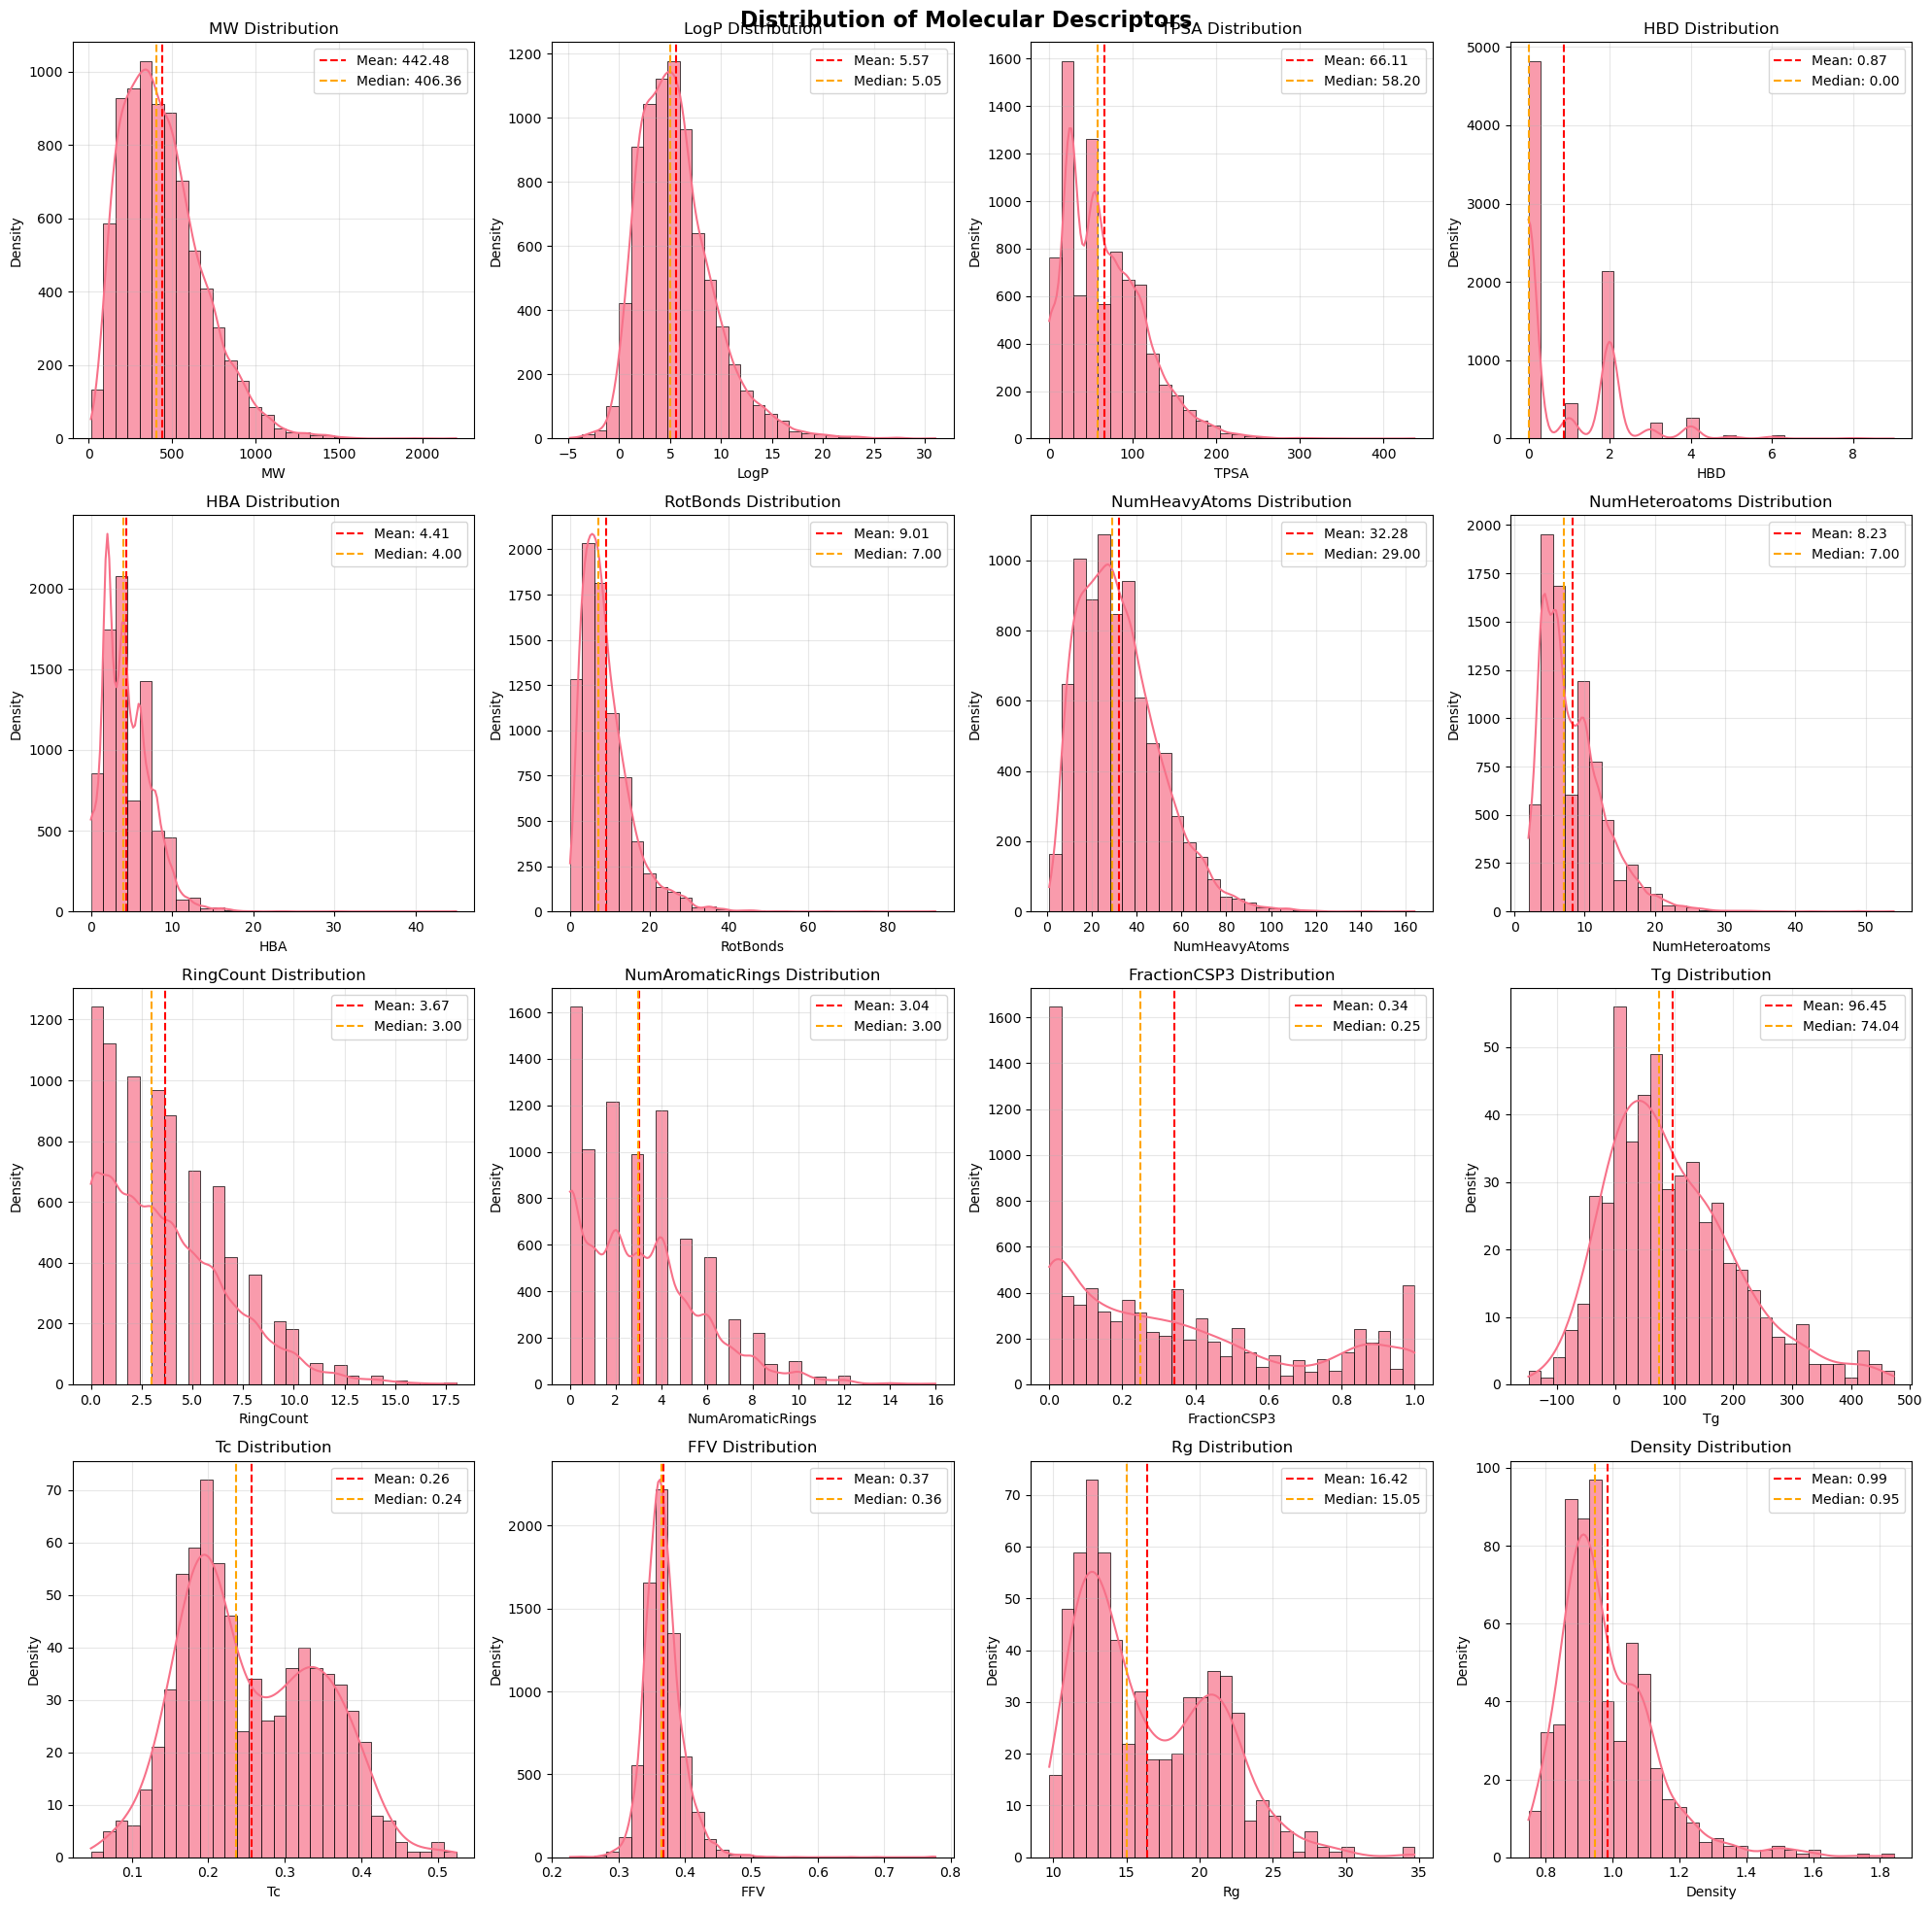

In [54]:
# Create visualizations for molecular descriptors
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4, 4, figsize=(20, 20)) # Increased grid size to 4x4
fig.suptitle('Distribution of Molecular Descriptors', fontsize=16, fontweight='bold')

# Define descriptors to plot
descriptors_to_plot = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds','NumHeavyAtoms','NumHeteroatoms','RingCount','NumAromaticRings', 'FractionCSP3','Tg','Tc','FFV','Rg','Density'] 

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, descriptor in enumerate(descriptors_to_plot):
    # Use the flattened axes array
    ax = axes[i]

    # Create histogram with density curve
    sns.histplot(data=df_with_descriptors, x=descriptor, bins=30, kde=True, ax=ax, alpha=0.7, # Added dropna() to handle NaNs
                       edgecolor='black', linewidth=0.5)


    # Add statistical information
    mean_val = df_with_descriptors[descriptor].mean()
    median_val = df_with_descriptors[descriptor].median()
    ax.axvline(mean_val, color='red', linestyle='--',
                          label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='orange', linestyle='--',
                          label=f'Median: {median_val:.2f}')

    ax.set_title(f'{descriptor} Distribution')
    ax.set_xlabel(descriptor)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide any unused subplots if the number of descriptors is less than the grid size
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

Correlation Analysis

Correlation Matrix for Molecular Descriptors:
                     Tg     Tc    FFV     Rg  Density     MW   LogP   TPSA  \
Tg                1.000  0.033    NaN  0.180    0.235  0.251  0.110  0.213   
Tc                0.033  1.000  0.150  0.555   -0.488  0.440  0.554  0.233   
FFV                 NaN  0.150  1.000  0.053   -0.214  0.162  0.305 -0.216   
Rg                0.180  0.555  0.053  1.000    0.091  0.339  0.257  0.265   
Density           0.235 -0.488 -0.214  0.091    1.000  0.046 -0.241  0.260   
MW                0.251  0.440  0.162  0.339    0.046  1.000  0.834  0.679   
LogP              0.110  0.554  0.305  0.257   -0.241  0.834  1.000  0.257   
TPSA              0.213  0.233 -0.216  0.265    0.260  0.679  0.257  1.000   
HBD               0.112  0.424 -0.331  0.330   -0.046  0.053 -0.027  0.294   
HBA               0.147  0.084 -0.148  0.167    0.344  0.699  0.323  0.913   
RotBonds         -0.321  0.723 -0.026  0.345   -0.302  0.547  0.518  0.404   
NumHeavyAtoms     

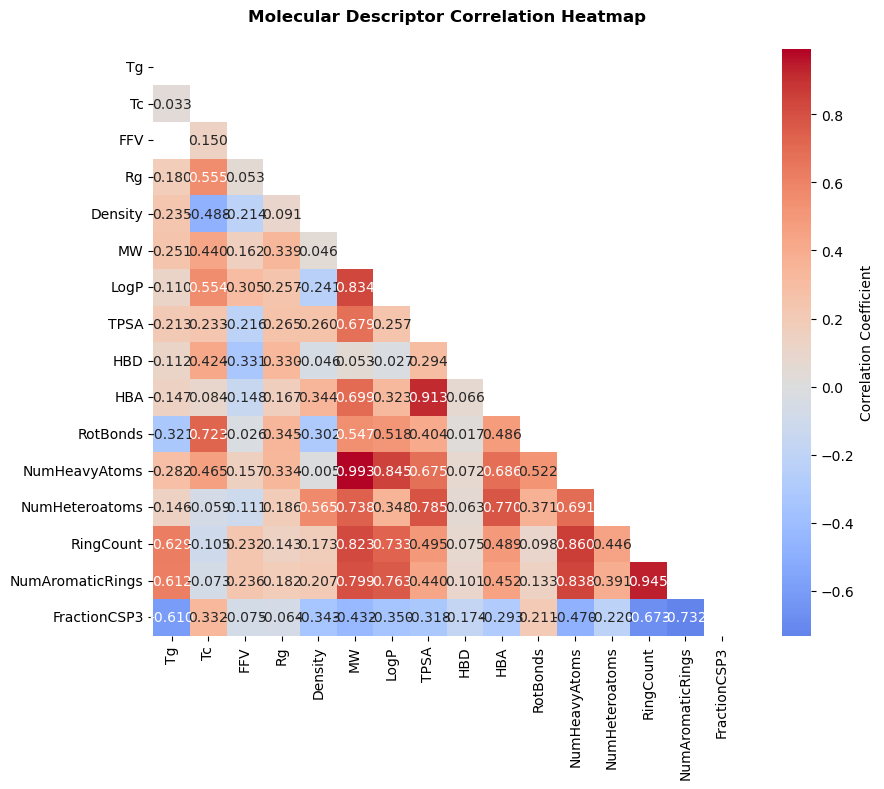

In [60]:
# Calculate correlation matrix for molecular descriptors
descriptor_cols = ['Tg','Tc','FFV','Rg','Density','MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds','NumHeavyAtoms','NumHeteroatoms','RingCount','NumAromaticRings', 'FractionCSP3']



# Calculate correlation matrix using .corr()
correlation_matrix = df_with_descriptors[descriptor_cols].corr()

# Display correlation matrix
print("Correlation Matrix for Molecular Descriptors:")
print(correlation_matrix.round(3))

# Create correlation heatmap
plt.figure(figsize=(10, 8))

# Use seaborn for a more informative heatmap
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(correlation_matrix,
            mask=mask,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Molecular Descriptor Correlation Heatmap', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Updated Heatmap: Removing FFV, MW, TPSA, HBD, HBA

Correlation Matrix for Selected Molecular Descriptors:
                     Tg     Tc  RotBonds     Rg   LogP  Density  \
Tg                1.000  0.033    -0.321  0.180  0.110    0.235   
Tc                0.033  1.000     0.723  0.555  0.554   -0.488   
RotBonds         -0.321  0.723     1.000  0.345  0.518   -0.302   
Rg                0.180  0.555     0.345  1.000  0.257    0.091   
LogP              0.110  0.554     0.518  0.257  1.000   -0.241   
Density           0.235 -0.488    -0.302  0.091 -0.241    1.000   
NumHeavyAtoms     0.282  0.465     0.522  0.334  0.845   -0.005   
FractionCSP3     -0.610  0.332     0.211 -0.064 -0.350   -0.343   
RingCount         0.629 -0.105     0.098  0.143  0.733    0.173   
NumAromaticRings  0.612 -0.073     0.133  0.182  0.763    0.207   

                  NumHeavyAtoms  FractionCSP3  RingCount  NumAromaticRings  
Tg                        0.282        -0.610      0.629             0.612  
Tc                        0.465         0.332     -0.

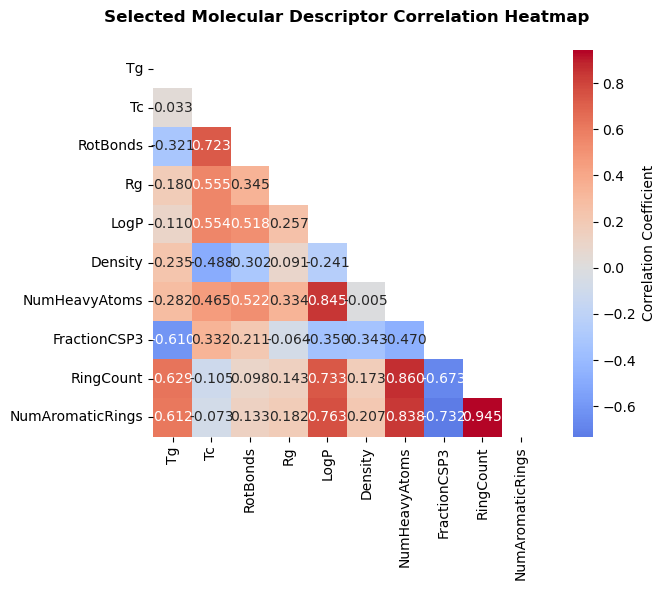

In [61]:
# Define the subset of descriptors for the new heatmap
selected_descriptors = ['Tg','Tc','RotBonds', 'Rg', 'LogP', 'Density', 'NumHeavyAtoms',
                        'FractionCSP3', 'RingCount', 'NumAromaticRings']

# Calculate the correlation matrix for the selected descriptors
selected_correlation_matrix = df_with_descriptors[selected_descriptors].corr()

# Display the correlation matrix
print("Correlation Matrix for Selected Molecular Descriptors:")
print(selected_correlation_matrix.round(3))

# Create a correlation heatmap for the selected descriptors
plt.figure(figsize=(8, 6))

# Use seaborn for a more informative heatmap
mask = np.triu(np.ones_like(selected_correlation_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(selected_correlation_matrix,
            mask=mask,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Selected Molecular Descriptor Correlation Heatmap', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Filtering by highest correlated features for Tg and Tc


--- Heatmap for Tg vs all features ---


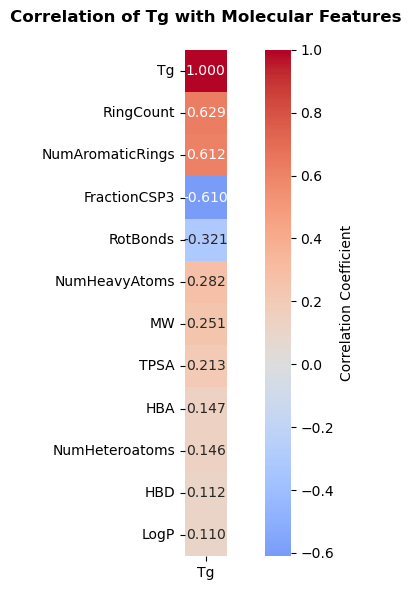


--- Heatmap for Tc vs all features ---


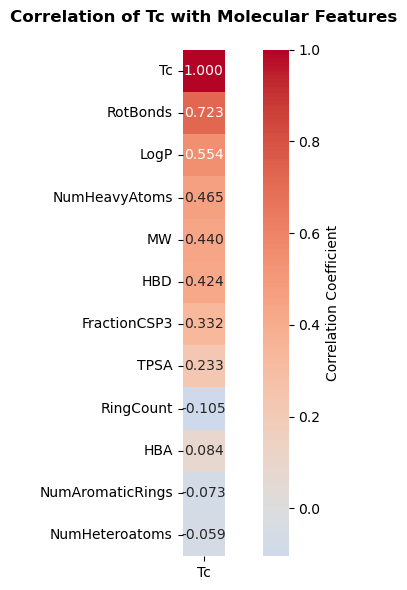

In [58]:
# Define the target properties and the feature columns
target_properties = ['Tg', 'Tc']
feature_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds','NumHeavyAtoms','NumHeteroatoms','RingCount','NumAromaticRings', 'FractionCSP3']


# Generate heatmaps for each target property
for target in target_properties:
    print(f"\n--- Heatmap for {target} vs all features ---")
    # Select the target column and feature columns
    cols_to_correlate = [target] + feature_cols

    # Calculate the correlation matrix
    correlation_matrix = df_with_descriptors[cols_to_correlate].corr()

    # Extract the correlations with the target property
    target_correlations = correlation_matrix[target].drop(target)

    # Sort the correlations by absolute value for better visualization
    sorted_correlations = target_correlations.abs().sort_values(ascending=False).index.tolist()
    sorted_correlations_with_target = [target] + sorted_correlations

    # Reorder the correlation matrix based on sorted correlations
    reordered_matrix = correlation_matrix.loc[sorted_correlations_with_target, sorted_correlations_with_target]


    plt.figure(figsize=(8, 6))
    sns.heatmap(reordered_matrix[[target]], # Only show the column for the current target
                annot=True,
                cmap='coolwarm',
                center=0,
                square=True,
                fmt='.3f',
                cbar_kws={'label': 'Correlation Coefficient'})

    plt.title(f'Correlation of {target} with Molecular Features', fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

Absolute Correlations of all Original Target Features with RDKit Features

In [62]:
# Calculate correlation matrix for molecular descriptors
descriptor_cols = ['Tg','Tc','FFV','Rg','Density','MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds','NumHeavyAtoms','NumHeteroatoms','RingCount','NumAromaticRings', 'FractionCSP3']

target_properties = ['Tg', 'Tc', 'FFV', 'Rg', 'Density']

# Calculate correlation matrix using .corr()
# Ensure all relevant columns are included in the correlation matrix calculation
all_cols_for_correlation = target_properties + [col for col in descriptor_cols if col not in target_properties]
correlation_matrix = df_with_descriptors[all_cols_for_correlation].corr()

# Rank correlations for each target property and display as tables
print("\nRanking of Correlations with Target Properties (Tables):")
for target in target_properties:
    # Get the correlation values for the current target property with ALL other columns
    correlations = correlation_matrix[target]

    # Sort the correlation values by their absolute value in descending order
    # Include the target's self-correlation
    sorted_correlations = correlations.abs().sort_values(ascending=False)

    # Create a DataFrame to display the ranked correlations
    ranked_df = pd.DataFrame({
        'Column': sorted_correlations.index,
        'Absolute Correlation': sorted_correlations.values,
        'Original Correlation': [correlation_matrix.loc[column, target] for column in sorted_correlations.index]
    })

    print(f"\n--- Correlations with {target} (ranked by absolute value): ---")
    display(ranked_df)



Ranking of Correlations with Target Properties (Tables):

--- Correlations with Tg (ranked by absolute value): ---


,Column,Absolute Correlation,Original Correlation
0,Tg,1.000000,1.000000
1,RingCount,0.628617,0.628617
2,NumAromaticRings,0.612252,0.612252
3,FractionCSP3,0.610485,-0.610485
4,RotBonds,0.320607,-0.320607
5,NumHeavyAtoms,0.281691,0.281691
6,MW,0.250809,0.250809
7,Density,0.235291,0.235291
8,TPSA,0.212706,0.212706
9,Rg,0.180072,0.180072



--- Correlations with Tc (ranked by absolute value): ---


,Column,Absolute Correlation,Original Correlation
0,Tc,1.000000,1.000000
1,RotBonds,0.722609,0.722609
2,Rg,0.554758,0.554758
3,LogP,0.554276,0.554276
4,Density,0.488476,-0.488476
5,NumHeavyAtoms,0.464714,0.464714
6,MW,0.439685,0.439685
7,HBD,0.424403,0.424403
8,FractionCSP3,0.331863,0.331863
9,TPSA,0.233444,0.233444



--- Correlations with FFV (ranked by absolute value): ---


,Column,Absolute Correlation,Original Correlation
0,FFV,1.000000,1.000000
1,HBD,0.330979,-0.330979
2,LogP,0.305414,0.305414
3,NumAromaticRings,0.235873,0.235873
4,RingCount,0.232342,0.232342
5,TPSA,0.215766,-0.215766
6,Density,0.214185,-0.214185
7,MW,0.161901,0.161901
8,NumHeavyAtoms,0.156700,0.156700
9,Tc,0.149878,0.149878



--- Correlations with Rg (ranked by absolute value): ---


,Column,Absolute Correlation,Original Correlation
0,Rg,1.000000,1.000000
1,Tc,0.554758,0.554758
2,RotBonds,0.344738,0.344738
3,MW,0.338763,0.338763
4,NumHeavyAtoms,0.334163,0.334163
5,HBD,0.330302,0.330302
6,TPSA,0.264673,0.264673
7,LogP,0.256600,0.256600
8,NumHeteroatoms,0.186147,0.186147
9,NumAromaticRings,0.182404,0.182404



--- Correlations with Density (ranked by absolute value): ---


,Column,Absolute Correlation,Original Correlation
0,Density,1.000000,1.000000
1,NumHeteroatoms,0.565235,0.565235
2,Tc,0.488476,-0.488476
3,HBA,0.343688,0.343688
4,FractionCSP3,0.342693,-0.342693
5,RotBonds,0.301770,-0.301770
6,TPSA,0.260343,0.260343
7,LogP,0.241021,-0.241021
8,Tg,0.235291,0.235291
9,FFV,0.214185,-0.214185


Scatter Plots for Top 3 Correlated Features for Each Original Target Feature

Generating scatter plots for top correlated descriptors:

--- Plots for Tg ---


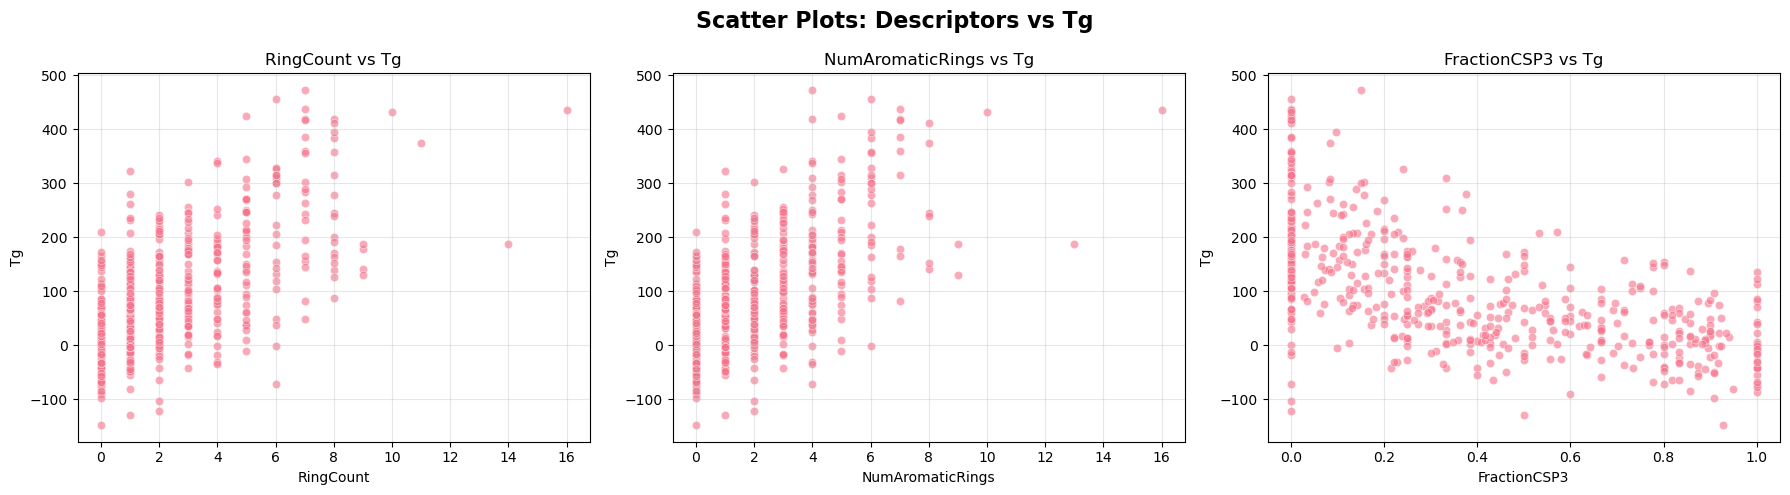


--- Plots for Tc ---


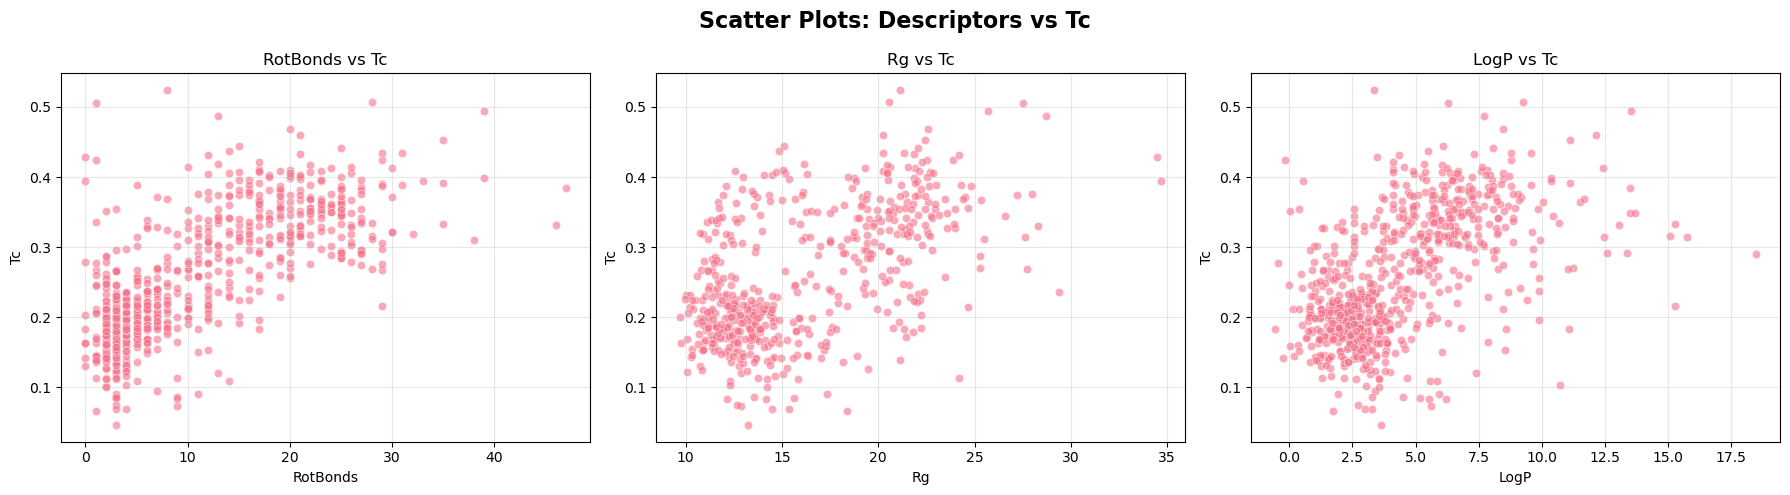


--- Plots for FFV ---


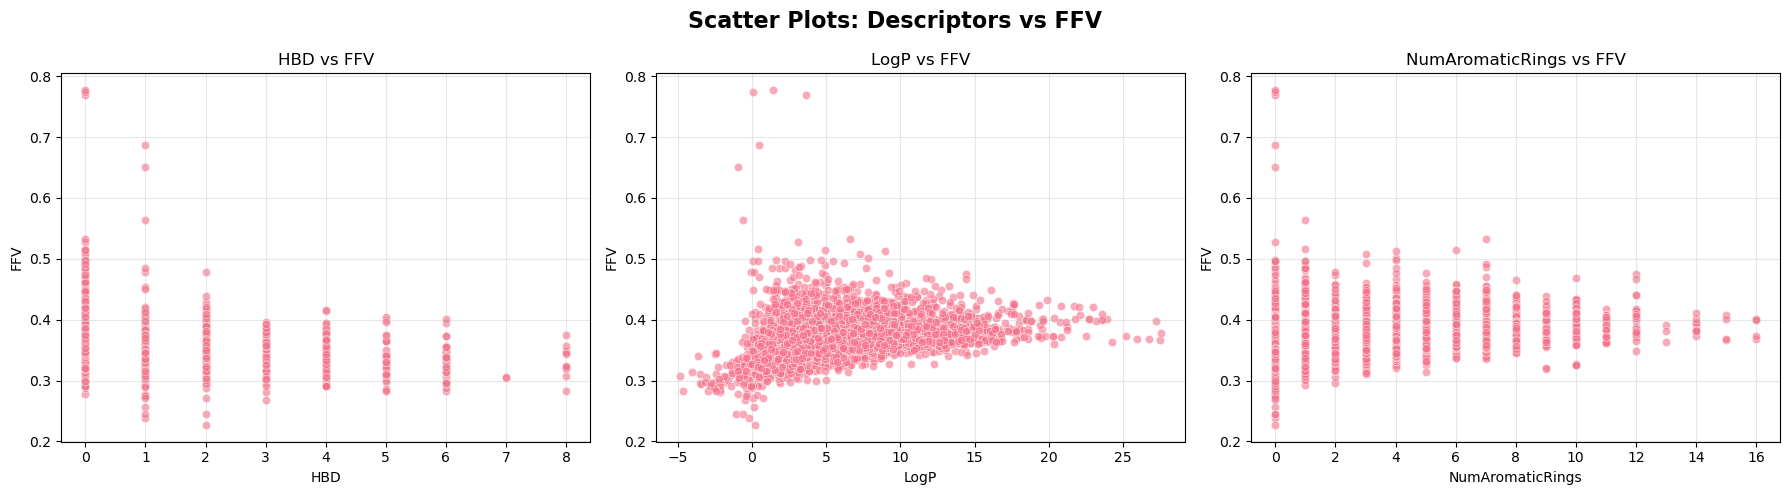


--- Plots for Rg ---


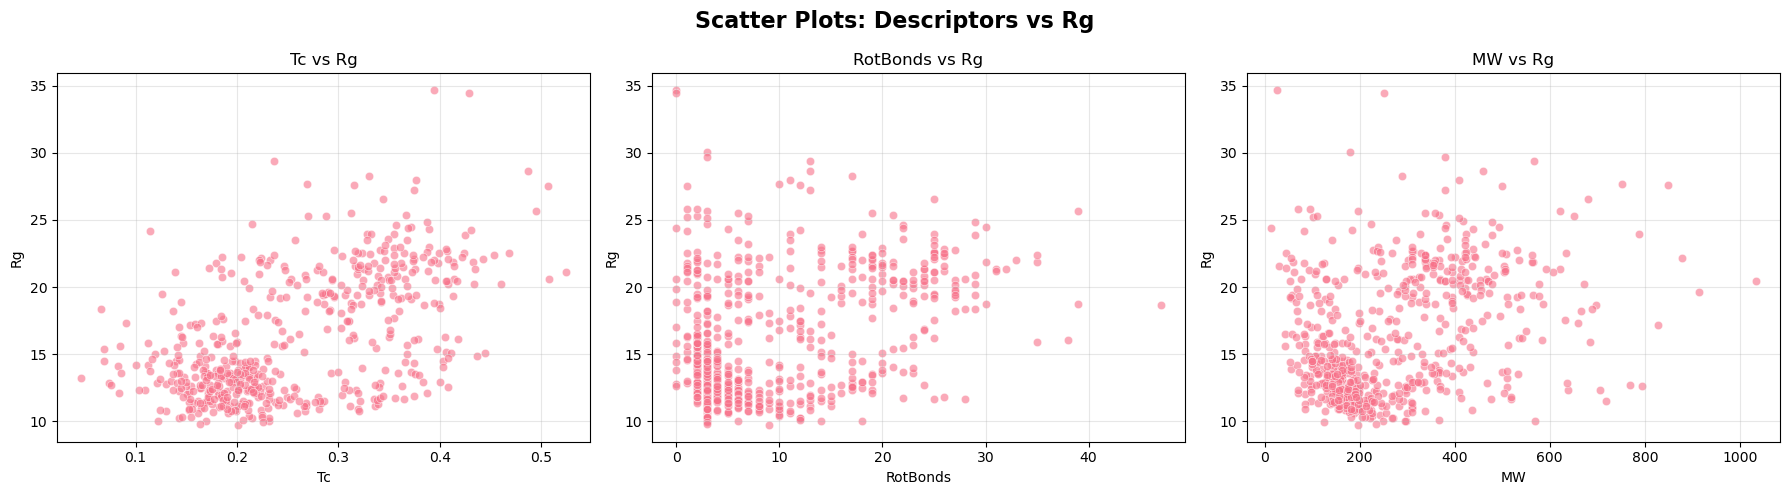


--- Plots for Density ---


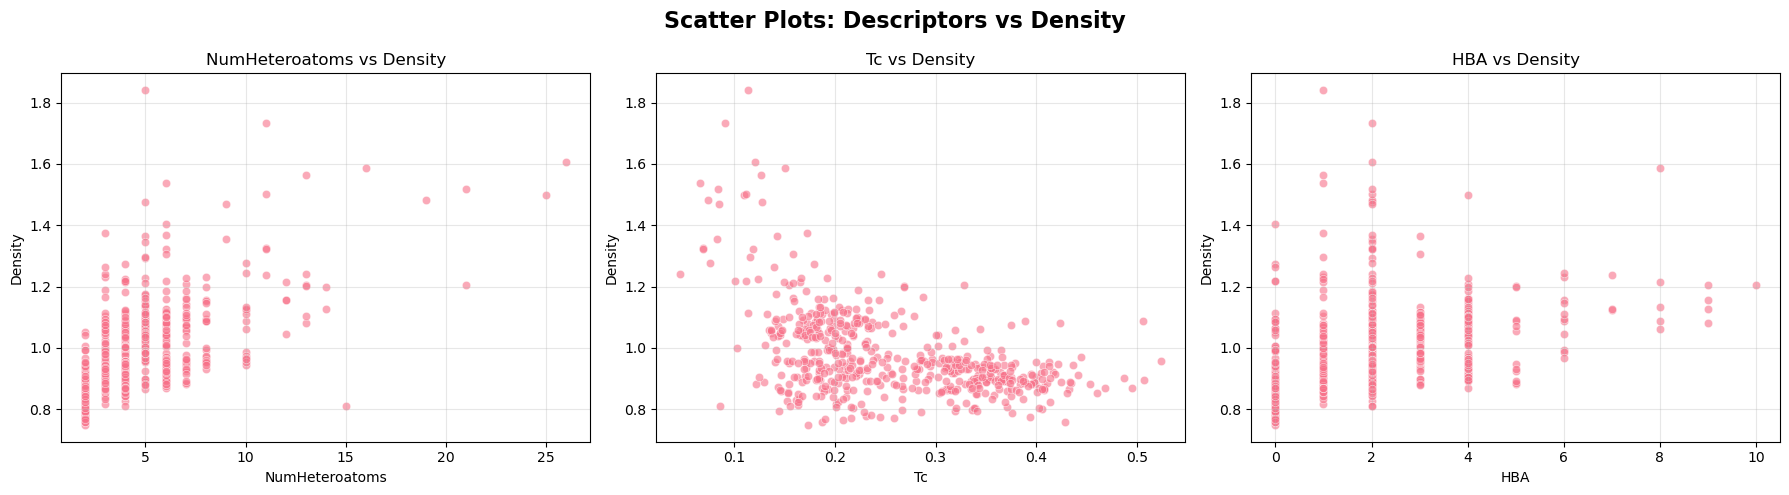

In [64]:
# Define target properties and the top N descriptors to visualize for each
target_properties = ['Tg', 'Tc', 'FFV', 'Rg', 'Density']
num_top_descriptors = 3 # Visualize top 3 correlated descriptors for each target

# Get the correlation matrix (assuming it's already calculated in df_with_descriptors)
# If not, you would need to recalculate it here:
descriptor_cols = ['Tg','Tc','FFV','Rg','Density','MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds','NumHeavyAtoms','NumHeteroatoms','RingCount','NumAromaticRings', 'FractionCSP3']
# Ensure df_with_descriptors is accessible
if 'df_with_descriptors' not in locals() and 'df_with_descriptors' not in globals():
    print("df_with_descriptors not found. Please run the cell that creates it.")
else:
    correlation_matrix = df_with_descriptors[descriptor_cols].corr()


    print("Generating scatter plots for top correlated descriptors:")

    for target in target_properties:
        print(f"\n--- Plots for {target} ---")
        # Get the correlation values for the current target property, excluding self-correlation
        correlations = correlation_matrix[target].drop(target)

        # Sort the absolute correlation values in descending order and get the top N descriptor names
        top_descriptors = correlations.abs().sort_values(ascending=False).head(num_top_descriptors).index.tolist()

        # Create scatter plots for the top descriptors
        if top_descriptors:
            # Determine the number of rows and columns for subplots
            n_plots = len(top_descriptors)
            n_cols = 3 # You can adjust the number of columns
            n_rows = (n_plots + n_cols - 1) // n_cols

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
            fig.suptitle(f'Scatter Plots: Descriptors vs {target}', fontsize=16, fontweight='bold')
            axes = axes.flatten() # Flatten the axes array for easy iteration

            for i, descriptor in enumerate(top_descriptors):
                ax = axes[i]
                sns.scatterplot(data=df_with_descriptors, x=descriptor, y=target, ax=ax, alpha=0.6)
                ax.set_title(f'{descriptor} vs {target}')
                ax.set_xlabel(descriptor)
                ax.set_ylabel(target)
                ax.grid(True, alpha=0.3)

            # Hide any unused subplots
            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])

            plt.tight_layout()
            plt.show()
        else:
            print(f"No top descriptors found for {target} (or perhaps correlation matrix was not available).")

Scatter Plots for Target Properties vs Other Target Properties